<a href="https://colab.research.google.com/github/spentapa3-lgtm/deeplearning-/blob/main/Long_Short_Term_Memory(LSTM)_Forward_Pass_and_BackwardPropagation_with_random_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch: 100 Loss: 3.1147461212363767
Epoch: 200 Loss: 0.5775224246038734
Epoch: 300 Loss: 0.13697477466192445
Epoch: 400 Loss: 0.07397599136510377
Epoch: 500 Loss: 0.05032872680099864
Training converged at epoch: 503

Final Loss: 0.04984803476023829

Final Predictions:
[[0.  ]
 [0.98]
 [0.01]]
[[0.01]
 [0.01]
 [0.98]]
[[0.99]
 [0.  ]
 [0.01]]

Final LSTM Weights and Biases:

Wf (Forget Gate Weights):
 [[ 0.4711 -0.4334  0.1953  0.2765 -1.013 ]
 [ 0.0953  0.4157  0.0572 -0.6376 -0.0376]]
bf (Forget Gate Bias):
 [[-0.6555]
 [-0.5857]]

Wi (Input Gate Weights):
 [[-0.6177  0.1719  0.2307  0.626   0.7293]
 [-0.2118 -0.1673  0.6516  1.1162 -0.0769]]
bi (Input Gate Bias):
 [[1.5308]
 [1.5762]]

Wo (Output Gate Weights):
 [[-0.595  -0.0387  0.0191  1.0904  0.8078]
 [-0.3309 -0.2423  0.8445  0.8263  0.0819]]
bo (Output Gate Bias):
 [[1.6768]
 [1.8791]]

Wc (Candidate Weights):
 [[-0.3339  0.7145 -0.5762 -1.3564  1.7102]
 [-0.4586  0.0278 -1.8807  1.6464  0.4514]]
bc (Candidate Bias):
 [[-0.2586

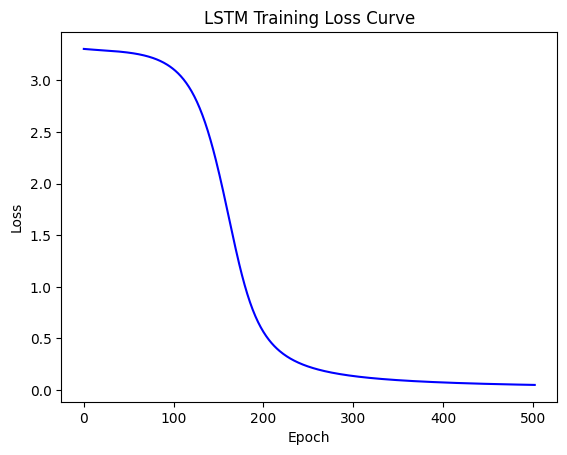

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)
def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-12))

input_size = 3
hidden_size = 2
output_size = 3
def init_gate():
    return np.random.randn(hidden_size, input_size + hidden_size) * 0.1
Wf = init_gate()
Wi = init_gate()
Wo = init_gate()
Wc = init_gate()
bf = np.zeros((hidden_size,1))
bi = np.zeros((hidden_size,1))
bo = np.zeros((hidden_size,1))
bc = np.zeros((hidden_size,1))
Why = np.random.randn(output_size, hidden_size) * 0.1
by = np.zeros((output_size,1))

x1 = np.array([[1],[0],[0]])
x2 = np.array([[0],[1],[0]])
x3 = np.array([[0],[0],[1]])
inputs = [x1, x2, x3]

t1 = np.array([[0],[1],[0]])
t2 = np.array([[0],[0],[1]])
t3 = np.array([[1],[0],[0]])
targets = [t1, t2, t3]

learning_rate = 0.1
threshold = 0.05
max_epochs = 1000
clip_value = 5
def clip_gradients(grad, clip_value):
    return np.clip(grad, -clip_value, clip_value)
loss_history = []

for epoch in range(max_epochs):

    h = np.zeros((hidden_size,1))
    c = np.zeros((hidden_size,1))
    hs, cs, zs = [h], [c], []
    fs, ins, os, c_tildes = [], [], [], []
    ps = []
    loss = 0
    for t in range(3):
        z = np.vstack((h, inputs[t]))
        zs.append(z)
        f = sigmoid(Wf @ z + bf)
        i = sigmoid(Wi @ z + bi)
        o = sigmoid(Wo @ z + bo)
        c_tilde = np.tanh(Wc @ z + bc)
        c = f * c + i * c_tilde
        h = o * np.tanh(c)
        y = Why @ h + by
        p = softmax(y)
        fs.append(f)
        ins.append(i)
        os.append(o)
        c_tildes.append(c_tilde)
        hs.append(h)
        cs.append(c)
        ps.append(p)
        loss += cross_entropy(targets[t], p)
    loss_history.append(loss)
    if loss < threshold:
        print("Training converged at epoch:", epoch+1)
        break

    dWf = np.zeros_like(Wf)
    dWi = np.zeros_like(Wi)
    dWo = np.zeros_like(Wo)
    dWc = np.zeros_like(Wc)
    dbf = np.zeros_like(bf)
    dbi = np.zeros_like(bi)
    dbo = np.zeros_like(bo)
    dbc = np.zeros_like(bc)
    dWhy = np.zeros_like(Why)
    dby = np.zeros_like(by)
    dh_next = np.zeros((hidden_size,1))
    dc_next = np.zeros((hidden_size,1))
    for t in reversed(range(3)):
        dy = ps[t] - targets[t]
        dWhy += dy @ hs[t+1].T
        dby += dy
        dh = Why.T @ dy + dh_next
        dc = dh * os[t] * (1 - np.tanh(cs[t+1])**2) + dc_next
        do = dh * np.tanh(cs[t+1])
        do_raw = do * os[t] * (1 - os[t])
        df = dc * cs[t]
        df_raw = df * fs[t] * (1 - fs[t])
        di = dc * c_tildes[t]
        di_raw = di * ins[t] * (1 - ins[t])
        dc_tilde = dc * ins[t]
        dc_tilde_raw = dc_tilde * (1 - c_tildes[t]**2)
        dWf += df_raw @ zs[t].T
        dWi += di_raw @ zs[t].T
        dWo += do_raw @ zs[t].T
        dWc += dc_tilde_raw @ zs[t].T
        dbf += df_raw
        dbi += di_raw
        dbo += do_raw
        dbc += dc_tilde_raw
        dz = (Wf.T @ df_raw +
              Wi.T @ di_raw +
              Wo.T @ do_raw +
              Wc.T @ dc_tilde_raw)
        dh_next = dz[:hidden_size, :]
        dc_next = dc * fs[t]

    for grad in [dWf,dWi,dWo,dWc,dWhy,dbf,dbi,dbo,dbc,dby]:
        np.clip(grad, -clip_value, clip_value, out=grad)

    Wf -= learning_rate * dWf
    Wi -= learning_rate * dWi
    Wo -= learning_rate * dWo
    Wc -= learning_rate * dWc
    Why -= learning_rate * dWhy
    bf -= learning_rate * dbf
    bi -= learning_rate * dbi
    bo -= learning_rate * dbo
    bc -= learning_rate * dbc
    by -= learning_rate * dby
    if (epoch+1) % 100 == 0:
        print("Epoch:", epoch+1, "Loss:", loss)
print("\nFinal Loss:", loss)

print("\nFinal Predictions:")
for t in range(3):
    print(np.round(ps[t], 2))

print("\nFinal LSTM Weights and Biases:\n")
print("Wf (Forget Gate Weights):\n", np.round(Wf, 4))
print("bf (Forget Gate Bias):\n", np.round(bf, 4))
print("\nWi (Input Gate Weights):\n", np.round(Wi, 4))
print("bi (Input Gate Bias):\n", np.round(bi, 4))
print("\nWo (Output Gate Weights):\n", np.round(Wo, 4))
print("bo (Output Gate Bias):\n", np.round(bo, 4))
print("\nWc (Candidate Weights):\n", np.round(Wc, 4))
print("bc (Candidate Bias):\n", np.round(bc, 4))
print("\nWhy (Output Layer Weights):\n", np.round(Why, 4))
print("by (Output Layer Bias):\n", np.round(by, 4))

plt.plot(loss_history, color='blue')
plt.title("LSTM Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()